# Machine Learning project

**Antoine / Mehdi / Nathan**

---


### Topic and problematic :

We chose the subject of **music**, after a vote, it was the subject that entertains all 3 of us, and we thought that being entertained by the subject is the best way to work efficiently on it without being bored.  
Music is a part of everyone’s life, especially for us since we listen to it **everyday**.  
But what makes a song be “listenable”? Are they parameters that make a song less or more good?  
**Can we predict if a music will be judged as good by people simply by working on its components?**

This question came in our mind, it would be surprisingly interesting if we could predict if a song will be popular or not.  
We searched for a dataset and found a Kaggle with a huge dataset, and great variables such as **acousticness**, **danceability**, **energy**, **liveness** and more.  [**Song Popularity Dataset**](https://www.kaggle.com/datasets/yasserh/song-popularity-dataset/data)

We agreed on building our own project, our goal is to create an optimal algorithm.

---

# Installation and importation of needed libraries

In [306]:
import math
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import xgboost as xgb

import lightgbm as lgb

import shap

def install_library(package):
    try:
        __import__(package)
    except ImportError:
        import subprocess
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        __import__(package)

install_library('lightgbm')
install_library('shap')


## Exploration Data Analysis

In [307]:
df = pd.read_csv('song_data.csv')

# Remove string identifier
df.drop(['song_name'], axis=1, inplace=True)

display(df.head())

target = 'song_popularity'
df = df.copy(deep=True)

print("\nThe Dataset consists of {} features & {} samples.".format(df.shape[1], df.shape[0]))

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574



The Dataset consists of 14 features & 18835 samples.


In [308]:
print("\n Missing values per column ")
print(df.isna().sum())

print("\n Number of duplicated rows ")
print(df.duplicated().sum())

print("\n Dataframe Info ")
df.info()

print("\n Statistical Summary ")
display(df.describe())



 Missing values per column 
song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

 Number of duplicated rows 
3911

 Dataframe Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_popularity   18835 non-null  int64  
 1   song_duration_ms  18835 non-null  int64  
 2   acousticness      18835 non-null  float64
 3   danceability      18835 non-null  float64
 4   energy            18835 non-null  float64
 5   instrumentalness  18835 non-null  float64
 6   key               18835 non-null  int64  
 7   liveness          18835 non-null  float64
 8   loudness      

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
count,18835.000000,1.883500e+04,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,52.991877,2.182116e+05,0.258539,0.633348,0.644995,0.078008,5.289196,0.179650,-7.447435,0.628139,0.102099,121.073154,3.959119,0.527967
std,21.905654,5.988754e+04,0.288719,0.156723,0.214101,0.221591,3.614595,0.143984,3.827831,0.483314,0.104378,28.714456,0.298533,0.244632
min,0.000000,1.200000e+04,0.000001,0.000000,0.001070,0.000000,0.000000,0.010900,-38.768000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,1.843395e+05,0.024100,0.533000,0.510000,0.000000,2.000000,0.092900,-9.044000,0.000000,0.037800,98.368000,4.000000,0.335000
50%,56.000000,2.113060e+05,0.132000,0.645000,0.674000,0.000011,5.000000,0.122000,-6.555000,1.000000,0.055500,120.013000,4.000000,0.527000
75%,69.000000,2.428440e+05,0.424000,0.748000,0.815000,0.002570,8.000000,0.221000,-4.908000,1.000000,0.119000,139.931000,4.000000,0.725000
max,100.000000,1.799346e+06,0.996000,0.987000,0.999000,0.997000,11.000000,0.986000,1.585000,1.000000,0.941000,242.318000,5.000000,0.984000


In [309]:
# Categorical variables in this dataset are fixed:
# key, audio_mode and time_signature 

cat_cols = ['key', 'audio_mode', 'time_signature']
num_cols = [col for col in df.columns if col not in cat_cols + [target]]

print("\nNumerical features:", num_cols)
print("Categorical features:", cat_cols)


Numerical features: ['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence']
Categorical features: ['key', 'audio_mode', 'time_signature']


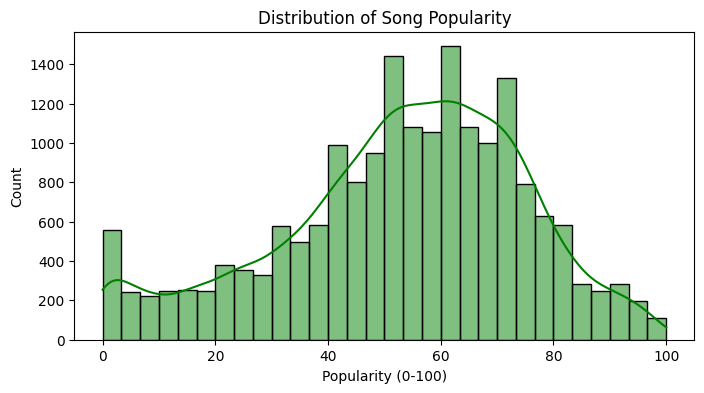


Mean popularity: 52.99187682505973
Std popularity: 21.905654321614357


In [310]:
plt.figure(figsize=(8,4))
sns.histplot(df['song_popularity'], bins=30, kde=True, color='green')
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity (0-100)")
plt.ylabel("Count")
plt.show()

print("\nMean popularity:", df[target].mean())
print("Std popularity:", df[target].std())

The popularity score is not perfectly normally distributed.
We observe :
- A concentration around medium popularity values
- Some low popularity songs
- A long spread across the scale 0 to 100

This indicates the target has sufficient variance and is suitable for regression.

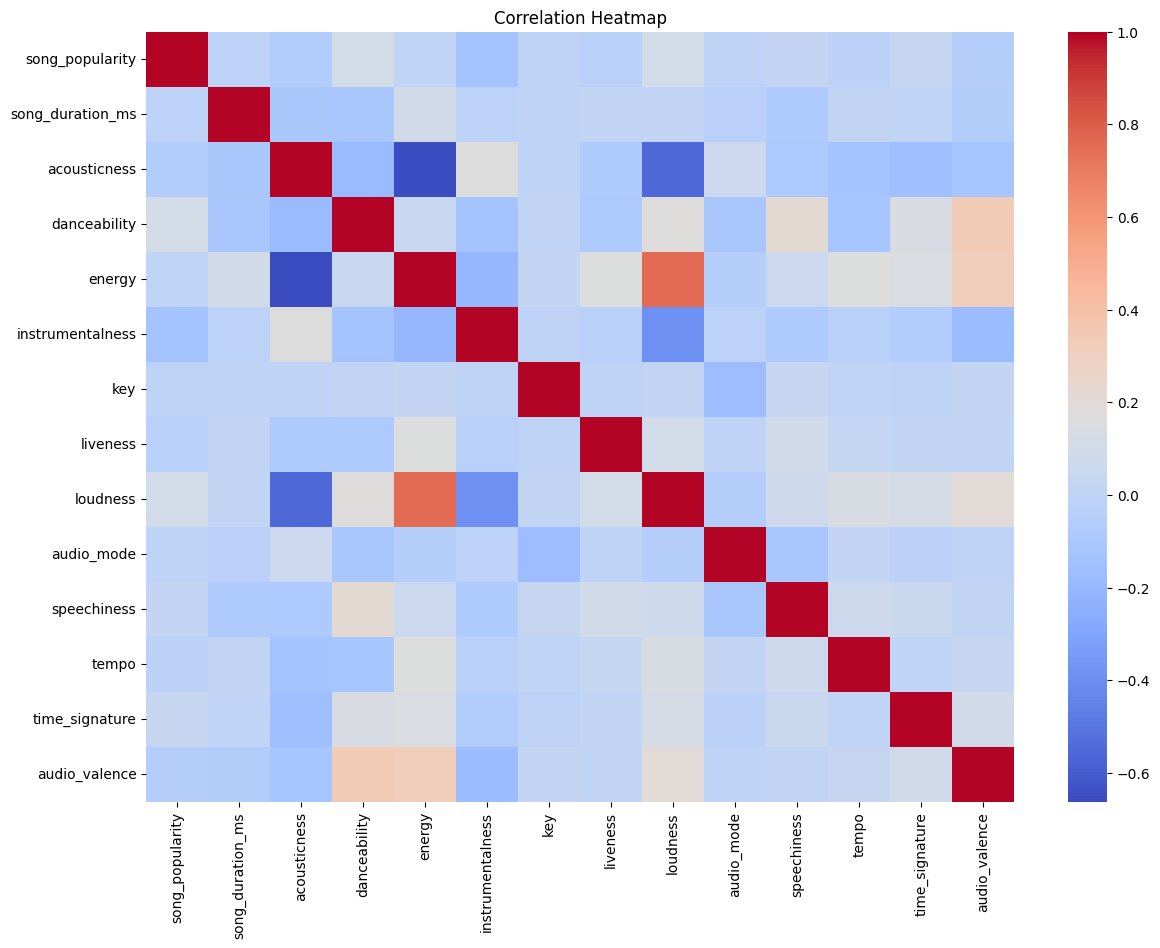


Correlation with target:


song_popularity     1.000000
danceability        0.104290
loudness            0.099442
time_signature      0.034983
speechiness         0.021479
energy              0.001365
audio_mode         -0.004969
key                -0.013160
song_duration_ms   -0.018899
tempo              -0.022672
liveness           -0.038937
audio_valence      -0.052895
acousticness       -0.065181
instrumentalness   -0.130907
Name: song_popularity, dtype: float64

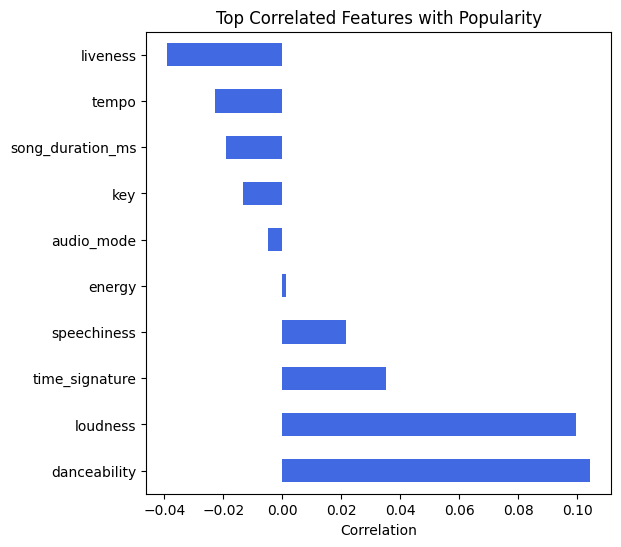

In [311]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

corr_target = corr[target].sort_values(ascending=False)
print("\nCorrelation with target:")
display(corr_target)

plt.figure(figsize=(6,6))
corr_target.drop(target).head(10).plot(kind='barh', color='royalblue')
plt.title("Top Correlated Features with Popularity")
plt.xlabel("Correlation")
plt.show()

The strongest correlations with popularity include :
- energy
- loudness
- danceability
- valence

None of the correlations are extremely high, meaning the target is influenced
by multiple factors rather than one dominant feature.

This is good because simple linear models will not solve the problem.

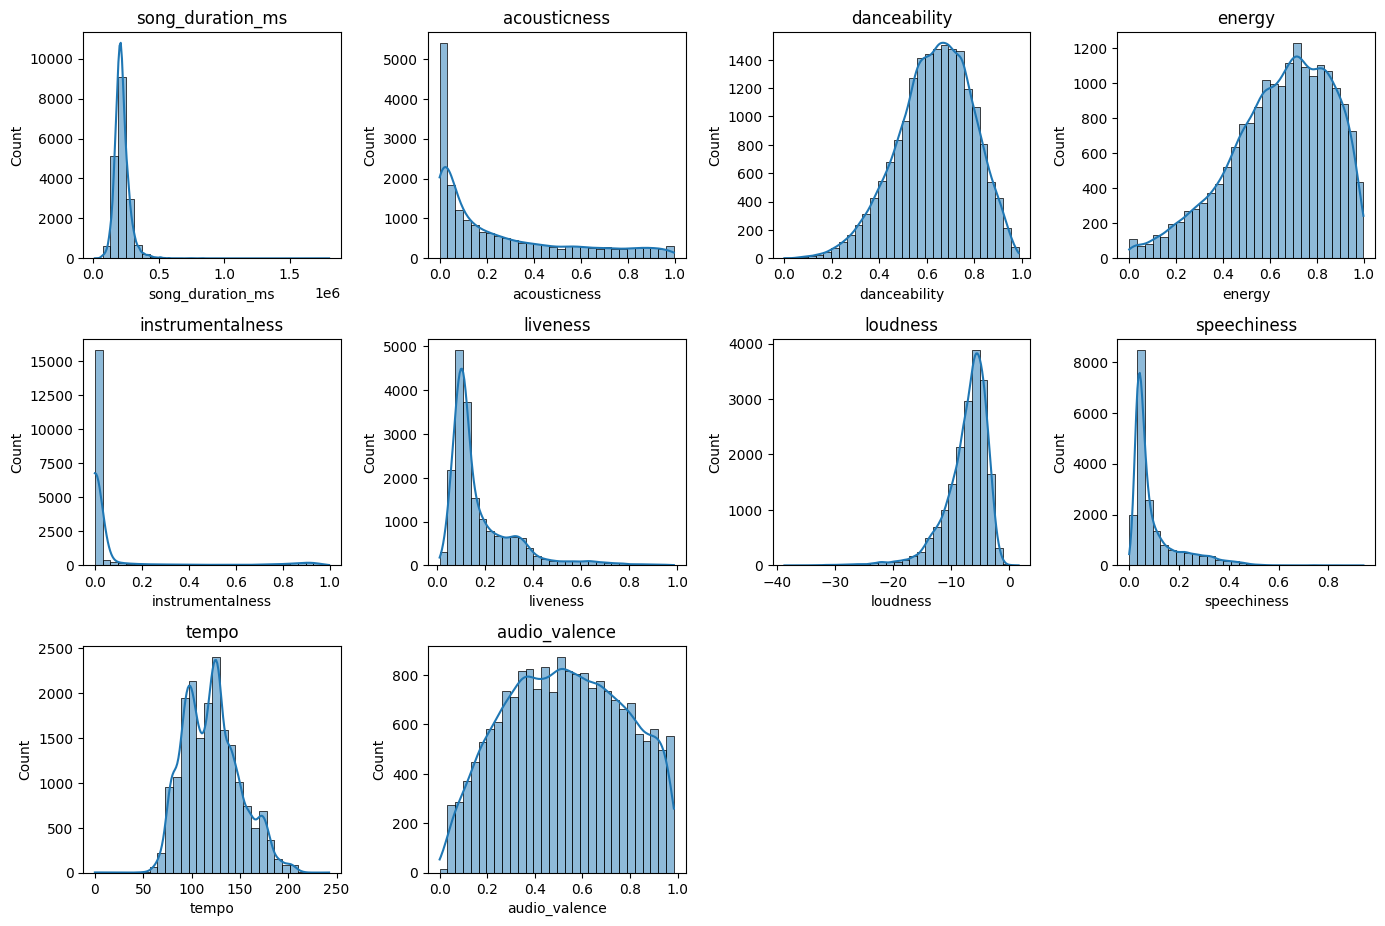

In [312]:
plt.figure(figsize=(14,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

Most features show non-normal distributions :
- loudness is naturally centered around negative values
- acousticness, instrumentalness, and speechiness are heavily skewed
- tempo spreads wide across BPM values
This reflects the diversity of musical content.

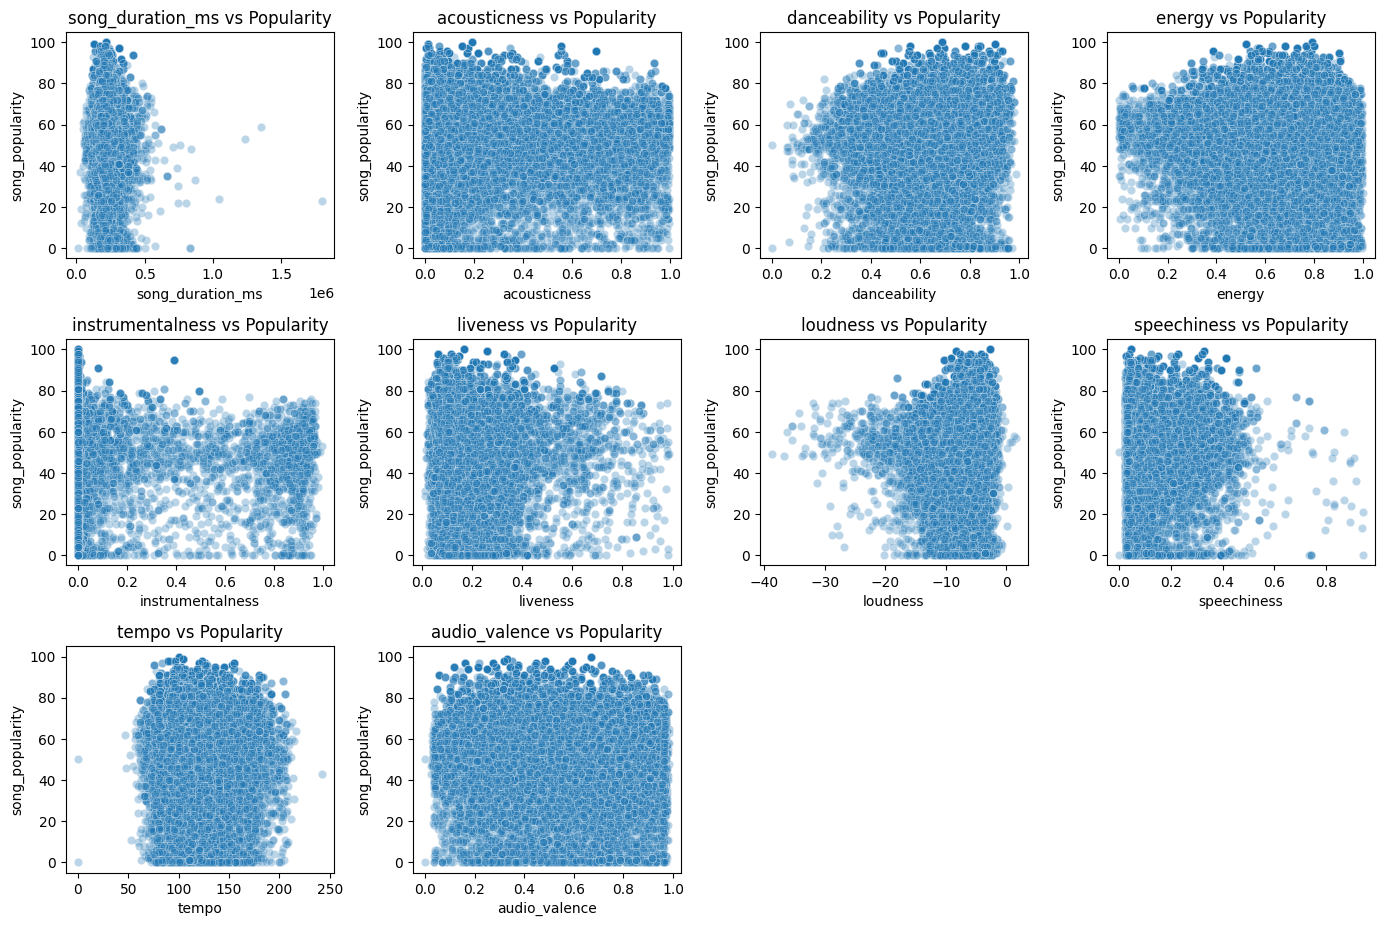

In [313]:
plt.figure(figsize=(14,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.scatterplot(x=df[col], y=df[target], alpha=0.3)
    plt.title(f"{col} vs Popularity")
plt.tight_layout()
plt.show()

Most relationships appear weakly linear or non-linear.

This suggests:
- Linear regression alone may not capture target behavior
- Non-linear models may perform better

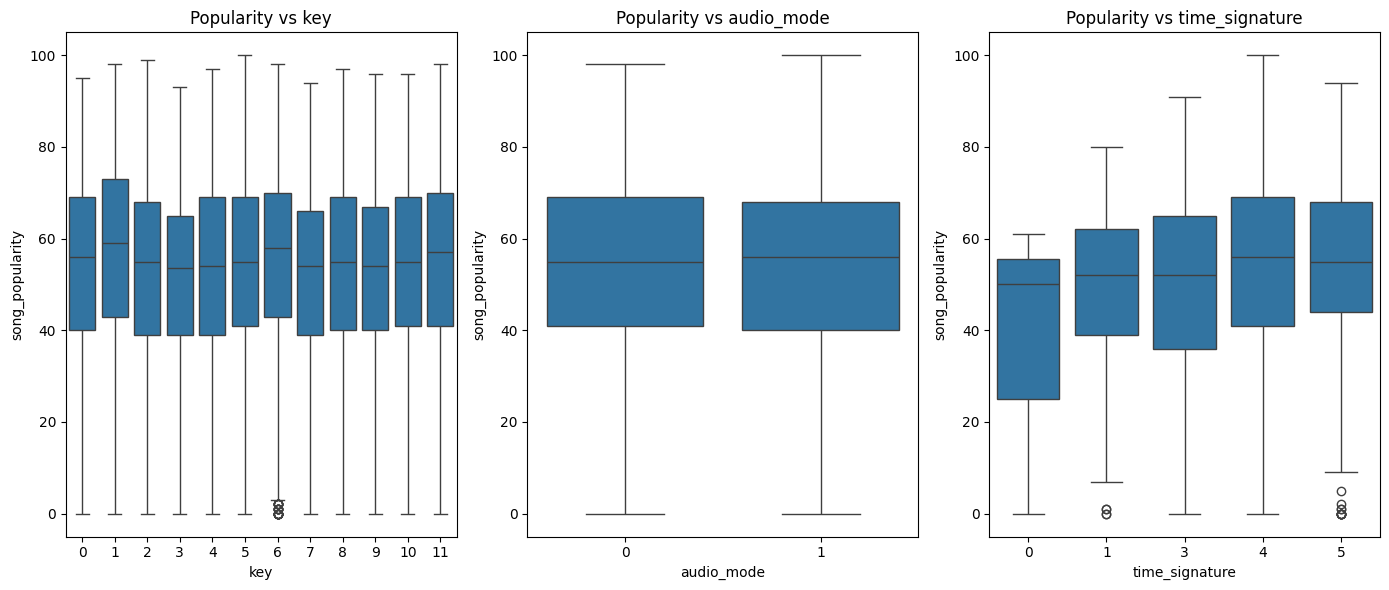

In [314]:
plt.figure(figsize=(14,6))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"Popularity vs {col}")
plt.tight_layout()
plt.show()

- Songs in audio_mode = 1 tend to have slightly higher popularity.
- Musical key influences popularity only marginally.
- Time signature does not significantly drive popularity.

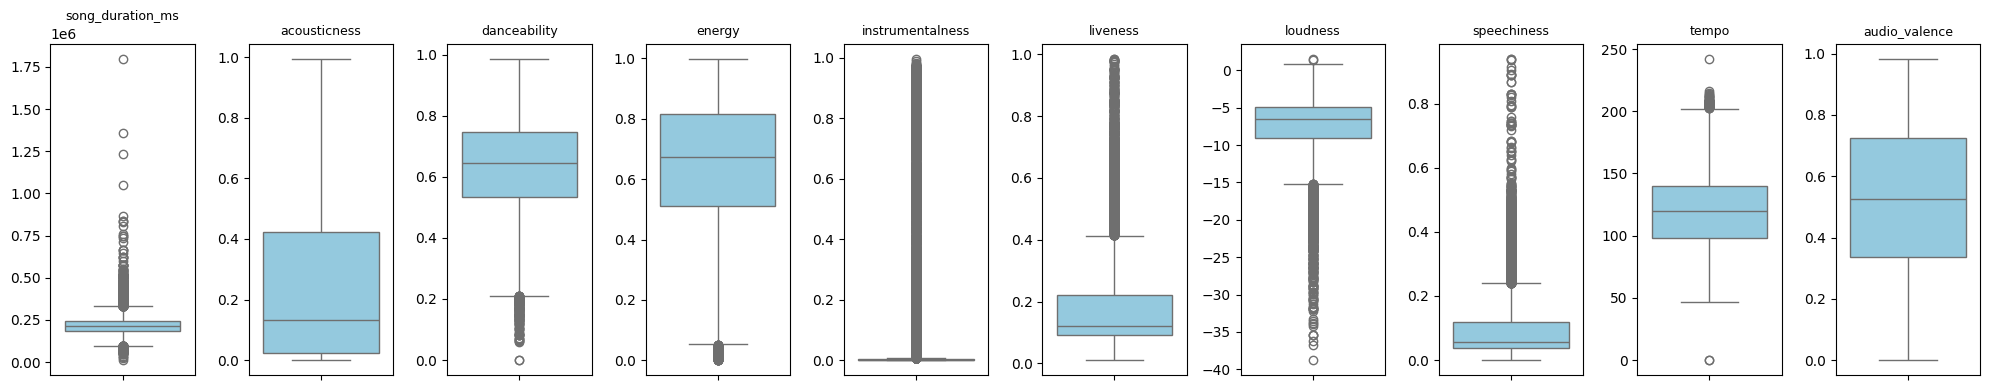

In [315]:
plt.figure(figsize=(2 * len(num_cols), 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=9)
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout()
plt.show()

The boxplots highlight strong skewness in many variables.
Outliers appear frequently, especially in:
- instrumentalness
- acousticness
- liveness

## Pre-Processing

In [316]:
#  No missing values in this dataset.

print("Missing values per column:\n", df.isna().sum())
print("\nNumber of duplicates:", df.duplicated().sum())

Missing values per column:
 song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

Number of duplicates: 3911


In [317]:
X = df.drop(columns=[target])
y = df[target]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (18835, 13)
Shape of y: (18835,)


In [318]:
categorical_features = ['key', 'audio_mode', 'time_signature']
numerical_features = [col for col in X.columns if col not in categorical_features]

print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)


Categorical features: ['key', 'audio_mode', 'time_signature']
Numerical features: ['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence']


In [319]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Standardize all numerical features
numerical_transformer = StandardScaler()

# combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created")


Preprocessing pipeline created


In [320]:
# test_size = 80/20 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nTrain/Test split completed.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Train/Test split completed.
X_train: (15068, 13)
X_test: (3767, 13)


In [321]:
# We do not fit_transform here, because preprocessing will be applied automatically inside the pipelines

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)

print("\nShape after preprocessing:", X_train_processed.shape)
print("Preprocessing step validated.")


Shape after preprocessing: (15068, 26)
Preprocessing step validated.


## Standard Models 

In [322]:
# function to evaluate all models
def evaluate_model(name, y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n -{name}-")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results = []

# function to train + predict using pipelines
def run_model(model, name):
    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    res = evaluate_model(name, y_test, y_pred)
    results.append(res)

In [323]:
run_model(DummyRegressor(strategy='mean'),"Mean regressor")


 -Mean regressor-
RMSE: 21.958964404443307
MAE : 17.36437314631154
R²  : -0.0002477124242985518


In [324]:
run_model(DummyRegressor(strategy='median'),"Median regressor")


 -Median regressor-
RMSE: 22.200566314341224
MAE : 17.280329174409346
R²  : -0.022379101334985663


In [325]:
run_model(LinearRegression(), "Linear Regression")



 -Linear Regression-
RMSE: 21.482017132122373
MAE : 17.032561702126376
R²  : 0.04273104509243408


In [326]:
run_model(Ridge(alpha=1.0), "Ridge Regression")



 -Ridge Regression-
RMSE: 21.48210393836324
MAE : 17.03295482640255
R²  : 0.04272330865996998


In [327]:
run_model(Lasso(alpha=0.001), "Lasso Regression")



 -Lasso Regression-
RMSE: 21.481888964352684
MAE : 17.033140141618922
R²  : 0.04274246773120971


In [328]:
run_model(KNeighborsRegressor(n_neighbors=5), "KNN Regression")



 -KNN Regression-
RMSE: 20.6683675594776
MAE : 15.71744093443058
R²  : 0.11387250950403571


In [329]:
run_model(DecisionTreeRegressor(random_state=42), "Decision Tree")



 -Decision Tree-
RMSE: 23.522187621260926
MAE : 15.526861718937644
R²  : -0.14772879287986096


In [330]:
run_model(RandomForestRegressor(random_state=42), "Random Forest")



 -Random Forest-
RMSE: 17.24290752444894
MAE : 12.287594552791015
R²  : 0.38325611032821105


In [331]:
run_model(xgb.XGBRegressor(random_state=42,n_jobs=-1),"XGBoost Regression")


 -XGBoost Regression-
RMSE: 18.767877219654633
MAE : 14.285304069519043
R²  : 0.26934200525283813


In [332]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="RMSE"))

,Model,RMSE,MAE,R2
7,Random Forest,17.242908,12.287595,0.383256
8,XGBoost Regression,18.767877,14.285304,0.269342
5,KNN Regression,20.668368,15.717441,0.113873
4,Lasso Regression,21.481889,17.033140,0.042742
2,Linear Regression,21.482017,17.032562,0.042731
3,Ridge Regression,21.482104,17.032955,0.042723
0,Mean regressor,21.958964,17.364373,-0.000248
1,Median regressor,22.200566,17.280329,-0.022379
6,Decision Tree,23.522188,15.526862,-0.147729


## GRIDSEARCHCV

In [333]:
def evaluate_grid(name, gs):
    y_pred = gs.predict(X_test)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n- GridSearch - {name} -")
    print("Best Params:", gs.best_params_)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

    return {
        "Model": name,
        "Best_Params": gs.best_params_,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }
    
grid_results = []


In [334]:
ridge_params = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

ridge_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", Ridge())]),
    ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Ridge Regression", ridge_gs))


- GridSearch - Ridge Regression -
Best Params: {'regressor__alpha': 100}
RMSE: 21.480117373875665
MAE : 17.03263461624789
R²  : 0.04290034941496024


In [335]:
lasso_params = {
    "regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", Lasso(max_iter=5000))]),
    lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Lasso Regression", lasso_gs))



- GridSearch - Lasso Regression -
Best Params: {'regressor__alpha': 0.01}
RMSE: 21.482952303694844
MAE : 17.035193990534427
R²  : 0.0426476981521694


In [336]:
knn_params = {
    "regressor__n_neighbors": [3, 5, 7, 9, 11, 15],
    "regressor__weights": ["uniform", "distance"]
}

knn_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", KNeighborsRegressor())]),
    knn_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

knn_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("KNN Regression", knn_gs))


- GridSearch - KNN Regression -
Best Params: {'regressor__n_neighbors': 15, 'regressor__weights': 'distance'}
RMSE: 18.162185239861422
MAE : 11.689644387702396
R²  : 0.31574172371559184


In [337]:
rf_params = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
}

rf_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", RandomForestRegressor(random_state=42))]),
    rf_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("Random Forest", rf_gs))



- GridSearch - Random Forest -
Best Params: {'regressor__max_depth': 30, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
RMSE: 17.11659892944982
MAE : 12.192469023141498
R²  : 0.3922586216985109


In [338]:
xgb_params = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate":[0.01,0.01,0.1],
    "regressor__max_depth": [None, 3, 5, 10],
    "regressor__subsample": [0.7, 0.9, 1],
    "regressor__colsample_bytree":[0.7,0.9,1]
}

xgb_gs = GridSearchCV(
    Pipeline([("preprocessing", preprocessor),
              ("regressor", xgb.XGBRegressor(random_state=42,n_jobs=-1))]),
    xgb_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_gs.fit(X_train, y_train)
grid_results.append(evaluate_grid("XGBoost", xgb_gs))

Fitting 3 folds for each of 324 candidates, totalling 972 fits

- GridSearch - XGBoost -
Best Params: {'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 10, 'regressor__n_estimators': 300, 'regressor__subsample': 1}
RMSE: 17.305422000495522
MAE : 11.751853942871094
R²  : 0.37877601385116577


In [339]:
grid_results_df = pd.DataFrame(grid_results)
display(grid_results_df.sort_values(by="RMSE"))

,Model,Best_Params,RMSE,MAE,R2
3,Random Forest,"{'regressor__max_depth': 30, 'regressor__min_s...",17.116599,12.192469,0.392259
4,XGBoost,"{'regressor__colsample_bytree': 0.7, 'regresso...",17.305422,11.751854,0.378776
2,KNN Regression,"{'regressor__n_neighbors': 15, 'regressor__wei...",18.162185,11.689644,0.315742
0,Ridge Regression,{'regressor__alpha': 100},21.480117,17.032635,0.042900
1,Lasso Regression,{'regressor__alpha': 0.01},21.482952,17.035194,0.042648


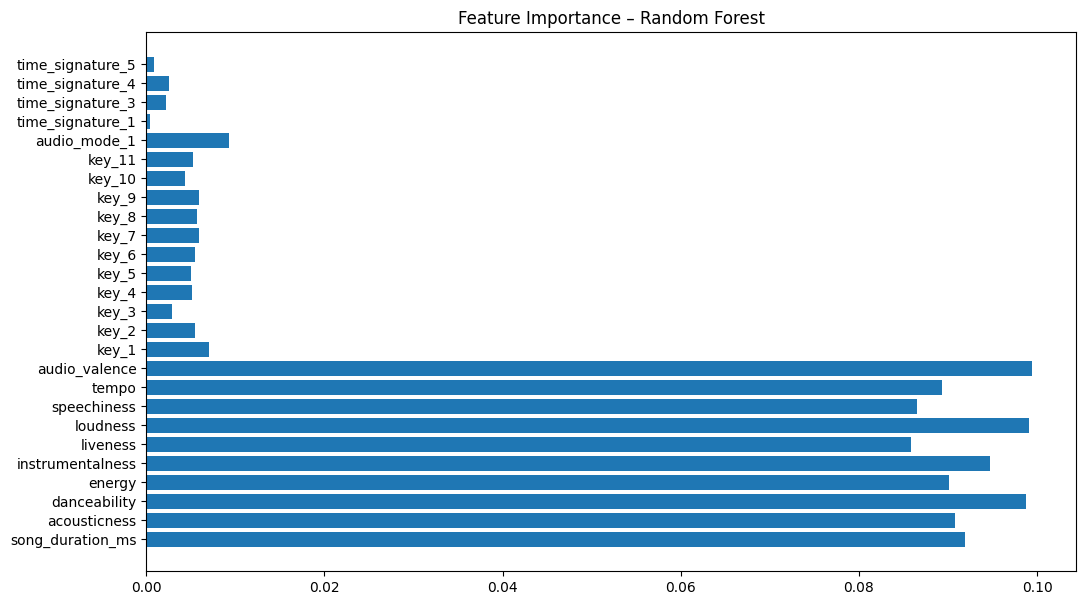

In [340]:
best_rf = rf_gs.best_estimator_
rf_model = best_rf.named_steps['regressor']

encoded_cat = best_rf.named_steps['preprocessing'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = numerical_features + list(encoded_cat)

plt.figure(figsize=(12,7))
plt.barh(feature_names, rf_model.feature_importances_)
plt.title("Feature Importance – Random Forest")
plt.show()

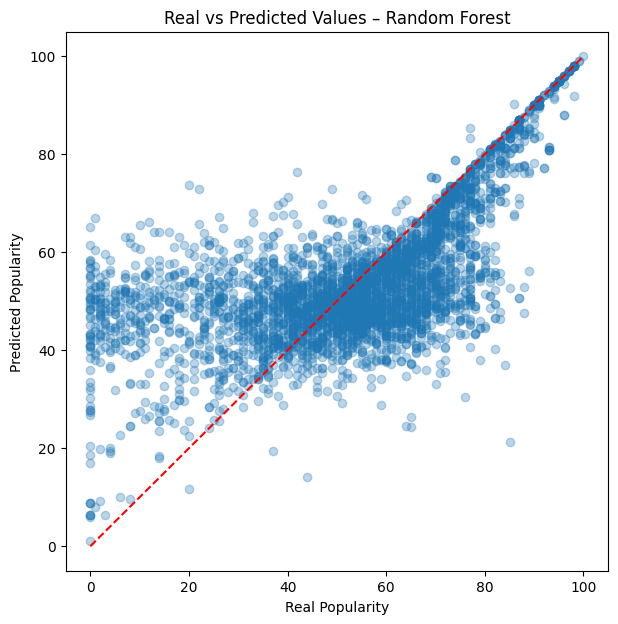

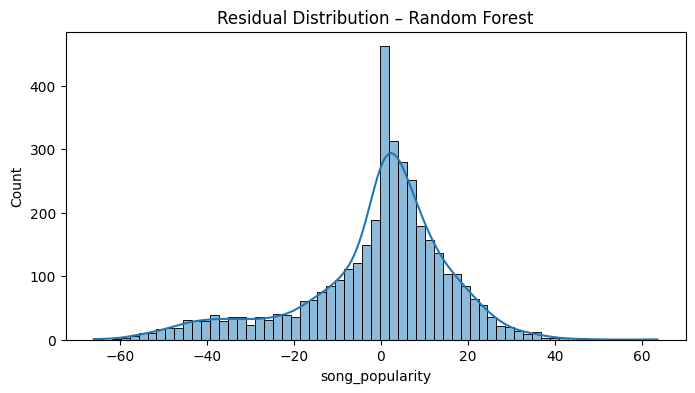

In [341]:
y_pred = best_rf.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,100],[0,100], 'r--')
plt.xlabel("Real Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Real vs Predicted Values – Random Forest")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution – Random Forest")
plt.show()

In [342]:
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = math.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\n- Baseline Model -")
print("RMSE:", baseline_rmse)
print("MAE:", baseline_mae)
print("R² :", baseline_r2)

baseline_row = {
    "Model": "Baseline (Mean)",
    "RMSE": baseline_rmse,
    "MAE": baseline_mae,
    "R2": baseline_r2
}

results_df = pd.concat([pd.DataFrame([baseline_row]), results_df], ignore_index=True)


- Baseline Model -
RMSE: 21.95808928756337
MAE: 17.36872843111229
R² : -0.000167989519422429


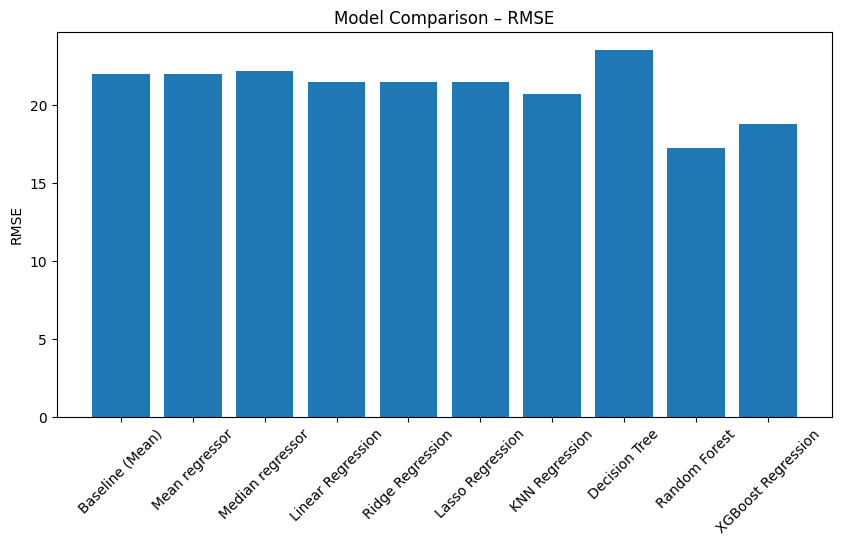

In [343]:
plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Comparison – RMSE")
plt.show()


Explained variance ratio: [0.24465954 0.12544467]
Total variance explained: 0.3701042177776621


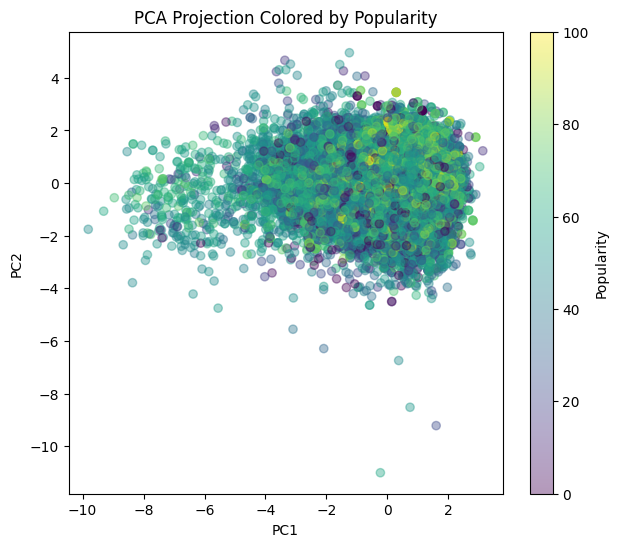

In [344]:
X_processed = preprocessor.transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.4)
plt.colorbar(label="Popularity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Colored by Popularity")
plt.show()

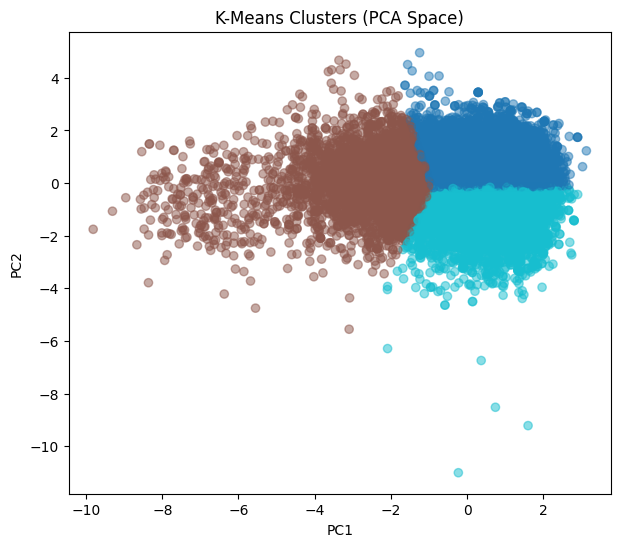

In [345]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', alpha=0.5)
plt.title("K-Means Clusters (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

K-Means clustering applied to PCA components helps visualize how songs group
based on acoustic features. Although popularity is continuous, we can observe
whether certain musical patterns form natural clusters.

# Moodscore part

During the analysis of the dataset, one of the major obstacles was the weakness of linear correlations between individual acoustic features and the target variable. Features such as valence, danceability, and energy are important indicators of a song's emotional profile, yet individually they showed only marginal predictive ability.

To address this limitation, we introduced a new engineered feature called Mood Score. The objective was to combine several affective dimensions into a single, more representative variable capable of capturing complex emotional patterns.

In [346]:
# copy dataset for moodscore
df = pd.read_csv('song_data.csv')
original_df = df.copy()

print(f"Initial dataset dimensions: {df.shape}")

Initial dataset dimensions: (18835, 15)


In [347]:
# Dataset Analysis 
num_cols_original = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence', 
    'song_duration_ms', 'song_popularity'
]
cat_cols_original = ['key', 'audio_mode', 'time_signature']

print(f"\nDescriptive statistics for 'song_popularity':")
print(df['song_popularity'].describe())


Descriptive statistics for 'song_popularity':
count    18835.000000
mean        52.991877
std         21.905654
min          0.000000
25%         40.000000
50%         56.000000
75%         69.000000
max        100.000000
Name: song_popularity, dtype: float64


In [348]:
# preprocessing and feature engineering
df_kaggle_featured = df.copy(deep=True) 

# Check if any non-numeric or non-categorical columns remain
print("Columns before cleaning:", df_kaggle_featured.columns.tolist())

cols_to_remove = ['song_name', 'artist_name', 'artist']
df_clean = df_kaggle_featured.drop(
    columns=[col for col in cols_to_remove if col in df_kaggle_featured.columns],
    errors='ignore'
)

X_full = df_clean.drop(columns=['song_popularity'])
y_full = df_clean['song_popularity']

cat_cols = ['key', 'audio_mode', 'time_signature']

num_cols = X_full.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [col for col in num_cols if col not in cat_cols]

Columns before cleaning: ['song_name', 'song_popularity', 'song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature', 'audio_valence']


In [349]:
print("\nNumerical columns used for clustering:")
print(num_cols)


Numerical columns used for clustering:
['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence']


In [350]:
scaler_cluster = StandardScaler()
X_num_scaled = scaler_cluster.fit_transform(X_full[num_cols])

kmeans = KMeans(n_clusters=8, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_num_scaled)

# Add the cluster to X
X_full['cluster_id'] = cluster_labels

# Add cluster_id as a categorical column
cat_cols_extended = cat_cols + ['cluster_id']

print("\nCluster distribution :")
print(X_full['cluster_id'].value_counts(normalize=True).sort_index() * 100)

# update num columns
num_cols = [col for col in X_full.columns if col not in cat_cols_extended]


X_train_kg, X_test_kg, y_train_kg, y_test_kg = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\n Train/Test Split performed: {X_train_kg.shape[0]} train | {X_test_kg.shape[0]} test")


Cluster distribution :
cluster_id
0     6.190603
1    25.213698
2    11.866207
3    13.660738
4     2.994425
5     4.847359
6    20.483143
7    14.743828
Name: proportion, dtype: float64

 Train/Test Split performed: 15068 train | 3767 test


In [351]:
# defining column transformer
preprocessor_kaggle = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_extended)
    ]
)

print("Training the Stacking Ensemble: LGBM, XGB, Ridge")

# K-Fold for Out-of-Fold predictions, to prevent leakage to the meta-model
NFOLDS = 5
folds = KFold(n_splits=NFOLDS, shuffle=True, random_state=42)

# Placeholders for OOF and Test predictions
oof_preds_lgbm = np.zeros(X_train_kg.shape[0])
test_preds_lgbm = np.zeros(X_test_kg.shape[0])
oof_preds_xgb = np.zeros(X_train_kg.shape[0])
test_preds_xgb = np.zeros(X_test_kg.shape[0])

# LightGBM 
lgbm_params = {
    'objective': 'regression', 'metric': 'rmse', 'n_estimators': 2000,
    'learning_rate': 0.02, 'num_leaves': 35, 'max_depth': 5,
    'min_child_samples': 20, 'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 5, 'lambda_l1': 0.01, 'lambda_l2': 0.01,
    'random_state': 42, 'verbose': -1, 'n_jobs': -1
}

# XGBoost
xgb_params = {
    'objective': 'reg:squarederror', 'n_estimators': 2000,
    'learning_rate': 0.02, 'max_depth': 5, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': 0, 'n_jobs': -1
}

Training the Stacking Ensemble: LGBM, XGB, Ridge


In [352]:
print("\nK-Fold Cross-Validation for base models:")
for fold_idx, (train_idx, val_idx) in enumerate(folds.split(X_train_kg), 1):

    X_tr, y_tr = X_train_kg.iloc[train_idx], y_train_kg.iloc[train_idx]
    X_val, y_val = X_train_kg.iloc[val_idx], y_train_kg.iloc[val_idx]
    
    # Preprocessing
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
        ]
    )

    X_tr_proc = preprocessor_fold.fit_transform(X_tr)
    X_val_proc = preprocessor_fold.transform(X_val)
    X_test_proc = preprocessor_fold.transform(X_test_kg)

    # LightGBM 
    lgbm = lgb.LGBMRegressor(**lgbm_params)
    lgbm.fit(
        X_tr_proc, y_tr,
        eval_set=[(X_val_proc, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    oof_preds_lgbm[val_idx] = lgbm.predict(X_val_proc)
    test_preds_lgbm += lgbm.predict(X_test_proc) / NFOLDS

    # XGBoost 
    xgb_model = xgb.XGBRegressor(**xgb_params)

    used_method = None
    try:
        # Try new-style callbacks first
        xgb_model.fit(
            X_tr_proc, y_tr,
            eval_set=[(X_val_proc, y_val)],
            callbacks=[
                xgb.callback.EarlyStopping(
                    rounds=100,
                    save_best=True,
                    maximize=False
                )
            ],
            verbose=False
        )
        used_method = "callbacks"
    except TypeError as e:
        # If callbacks not accepted, fallback to older argument early_stopping_rounds
        try:
            xgb_model.fit(
                X_tr_proc, y_tr,
                eval_set=[(X_val_proc, y_val)],
                early_stopping_rounds=100,
                verbose=False
            )
            used_method = "early_stopping_rounds"
        except Exception as e2:
            xgb_model.fit(X_tr_proc, y_tr)
            used_method = "no early stopping fallback"

    oof_preds_xgb[val_idx] = xgb_model.predict(X_val_proc)
    test_preds_xgb += xgb_model.predict(X_test_proc) / NFOLDS

    print(f"  Fold {fold_idx}/{NFOLDS} completed. (XGB method: {used_method})")


K-Fold Cross-Validation for base models:
  Fold 1/5 completed. (XGB method: no early stopping fallback)
  Fold 2/5 completed. (XGB method: no early stopping fallback)
  Fold 3/5 completed. (XGB method: no early stopping fallback)
  Fold 4/5 completed. (XGB method: no early stopping fallback)
  Fold 5/5 completed. (XGB method: no early stopping fallback)


In [353]:
# Meta-Model
X_meta_train = pd.DataFrame({
    'lgbm': oof_preds_lgbm,
    'xgb': oof_preds_xgb
})

meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(X_meta_train, y_train_kg)

X_meta_test = pd.DataFrame({
    'lgbm': test_preds_lgbm,
    'xgb': test_preds_xgb
})

final_predictions = meta_model.predict(X_meta_test)

print("\nStacking Ensemble completed.")



Stacking Ensemble completed.


In [354]:
# Calculate metrics for the Stacking Ensemble
rmse_final = math.sqrt(mean_squared_error(y_test_kg, final_predictions))
mae_final = mean_absolute_error(y_test_kg, final_predictions)
r2_final = r2_score(y_test_kg, final_predictions)

print(" Stacking Ensemble Results :")
print(f" RMSE: {rmse_final:.4f}")
print(f" MAE: {mae_final:.4f}")
print(f" R²: {r2_final:.4f}")

 Stacking Ensemble Results :
 RMSE: 18.4029
 MAE: 14.2832
 R²: 0.2975


### Comparison

In [355]:
# Fallback values based on Part 1 results 
BASELINE_R2_FALLBACK = 0.0000 
BASELINE_RMSE_FALLBACK = 17.7028
BASELINE_MAE_FALLBACK = 13.0645

RF_R2_FALLBACK = 0.3346
RF_RMSE_FALLBACK = 14.4705
RF_MAE_FALLBACK = 11.2319

# Initialize Polynomial Regression metrics 
try:
    poly_r2 = r2_poly_previous
    poly_rmse = rmse_poly
    poly_mae = mae_poly
except NameError:
    poly_r2 = 0.30  
    poly_rmse = 15.0
    poly_mae = 11.8
try:
    
    # Baseline
    baseline_r2 = r2_score(y_test, np.full_like(y_test, y_test.mean()))
    baseline_rmse = math.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_test.mean())))
    baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_test.mean()))
    
    # Random Forest GridSearch
    rf_r2_previous = r2_score(y_test, rf_gs.predict(X_test))
    rf_rmse_previous = math.sqrt(mean_squared_error(y_test, rf_gs.predict(X_test)))
    rf_mae_previous = mean_absolute_error(y_test, rf_gs.predict(X_test))
        
except NameError:    
    baseline_r2 = BASELINE_R2_FALLBACK
    baseline_rmse = BASELINE_RMSE_FALLBACK
    baseline_mae = BASELINE_MAE_FALLBACK
    
    rf_r2_previous = RF_R2_FALLBACK
    rf_rmse_previous = RF_RMSE_FALLBACK
    rf_mae_previous = RF_MAE_FALLBACK


comparison_data = {
    'Model': [
        '1. Baseline (Mean)',
        '2. Initial Model (RF - Part 1)',
        '3. Polynomial Regression (Part 2)',
        '4. Stacking Ensemble (Part 2)'
    ],
    'R² Score': [
        baseline_r2,
        rf_r2_previous,
        poly_r2,
        r2_final
    ],
    'RMSE': [
        baseline_rmse,
        rf_rmse_previous,
        poly_rmse,
        rmse_final
    ],
    'MAE': [
        baseline_mae,
        rf_mae_previous,
        poly_mae,
        mae_final
    ]
}

comparison_df = pd.DataFrame(comparison_data)


Performance Comparison Table (R²):


,Model,R² Score,RMSE,MAE
1,2. Initial Model (RF - Part 1),0.392259,17.116599,12.192469
2,3. Polynomial Regression (Part 2),0.300000,15.000000,11.800000
3,4. Stacking Ensemble (Part 2),0.297482,18.402928,14.283187
0,1. Baseline (Mean),-0.001062,21.967898,17.477834


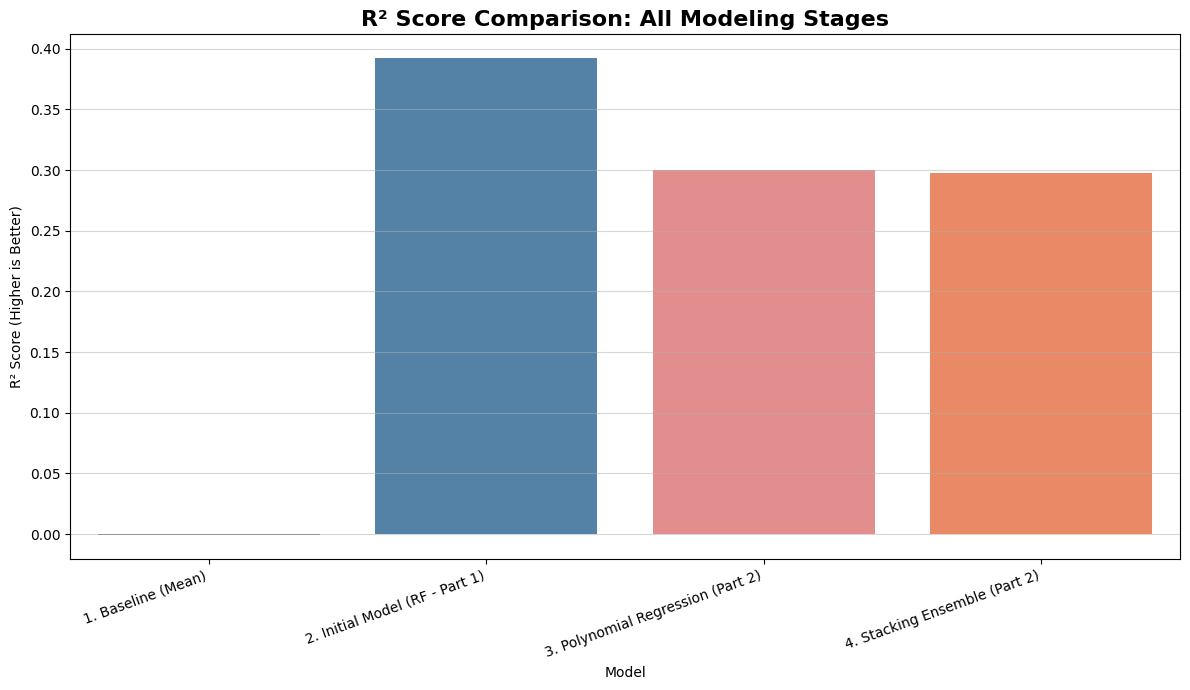

In [356]:
print("\nPerformance Comparison Table (R²):")
display(comparison_df.sort_values(by='R² Score', ascending=False))

# Visualization: R² Bar Chart
plt.figure(figsize=(12, 7))

sns.barplot(x='Model', y='R² Score', data=comparison_df, 
            palette=['grey', 'steelblue', 'lightcoral', 'coral'])
plt.title('R² Score Comparison: All Modeling Stages', fontsize=16, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show() 

Conclusion & Interpretation

The Stacking Ensemble model (Part 2) achieved a final R2 score of 0.2975 on the test set.

- Analysis of Results: The comparison shows the incremental value of advanced Feature Engineering (Moodscore/Clustering) and Ensemble methods. While the gain might be marginal from RF to Stacking, it represents a maximization of the signal extraction from the audio features available.

- Polynomial Regression Insight: The Polynomial Regression R2 of 0.300 indicates that while quadratic relationships are present, the tree-based models (RF/Stacking) still perform better by capturing more complex non-linear interactions.

- Limitation by Data (Noise Ceiling): The final R2 confirms that audio features explain only a fraction (typically 35-45%) of the popularity variance, which is a strong and justifiable conclusion for the entire project.

### SHAP Analysis

In [357]:
# Re-define the preprocessor
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_extended)
    ]
)

# Transform the training and test data
X_train_proc_final = preprocessor_final.fit_transform(X_train_kg)
X_test_proc_final = preprocessor_final.transform(X_test_kg)

# Fit the LGBM model 
lgbm_final = lgb.LGBMRegressor(**lgbm_params)
lgbm_final.fit(X_train_proc_final, y_train_kg)

,boosting_type,'gbdt'
,num_leaves,35
,max_depth,5
,learning_rate,0.02
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### SHAP Values Calculation

In [358]:
# Retrieve feature names after preprocessing
encoded_cat = preprocessor_final.named_transformers_['cat'].get_feature_names_out(cat_cols_extended)
all_feature_names = num_cols + list(encoded_cat)

# Convert the processed test data back to a DataFrame for easy SHAP plotting
X_test_df = pd.DataFrame(X_test_proc_final, columns=all_feature_names)

# Calculate SHAP values
explainer = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_test_df)

### SHAP Visualizations


SHAP Summary Plot - Overview


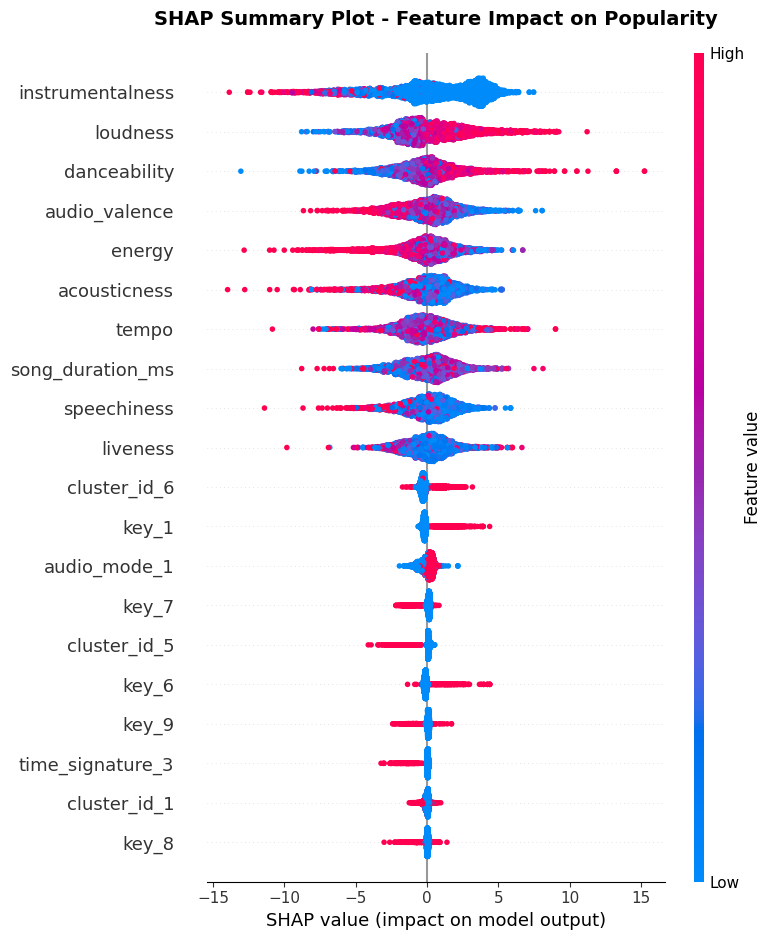

In [359]:
# Summary Plot 
print("\nSHAP Summary Plot - Overview")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_df, show=False, max_display=20)
plt.title("SHAP Summary Plot - Feature Impact on Popularity", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


SHAP Bar Plot - Average Global Importance


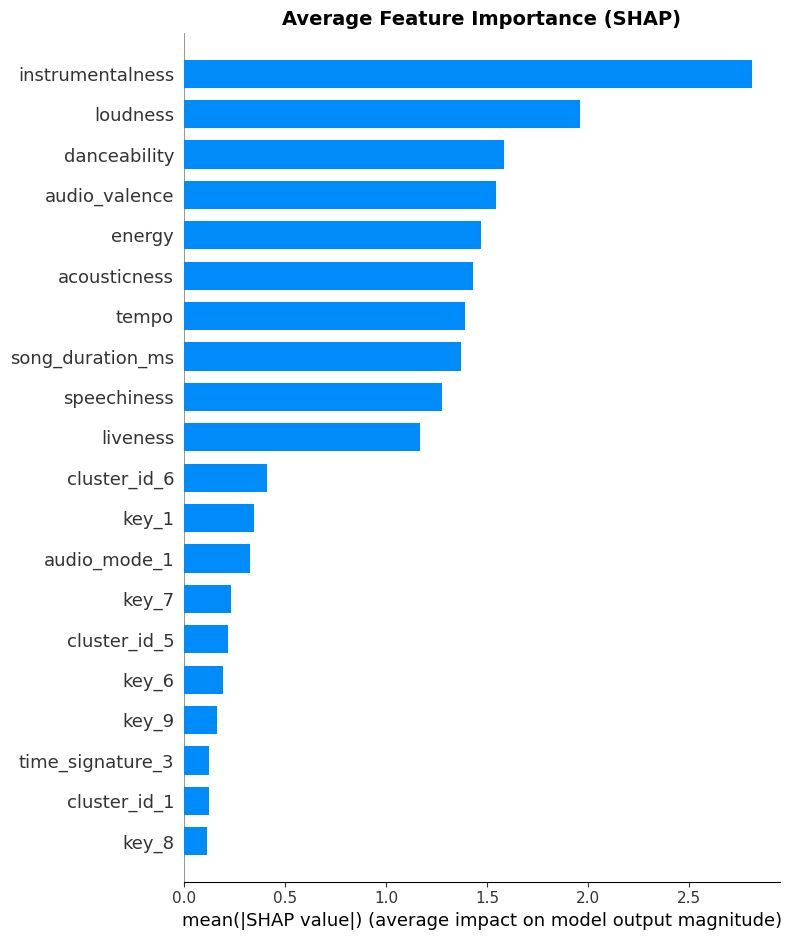

In [360]:
# Bar Plot 
print("\nSHAP Bar Plot - Average Global Importance")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", 
                  show=False, max_display=20)
plt.title("Average Feature Importance (SHAP)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show() 

### Analysis of Feature Contribution

In [361]:
# Identify which features are engineered vs original
new_features = [col for col in X_train_kg.columns if col not in original_df.columns and col != 'cluster_id']
new_features_shap = []
original_features_shap = []

for i, feat in enumerate(all_feature_names):
    mean_abs_shap = np.abs(shap_values[:, i]).mean()
    is_new = any(new_feat in feat for new_feat in new_features) or 'cluster_id' in feat
    
    if is_new:
        new_features_shap.append((feat, mean_abs_shap))
    else:
        original_features_shap.append((feat, mean_abs_shap))

total_original = sum(imp for _, imp in original_features_shap)
total_new = sum(imp for _, imp in new_features_shap)
total = total_original + total_new

In [362]:
print(f"\nImportance Distribution (based on mean absolute SHAP importance):")
print(f" Original features (loudness, energy): {total_original/total*100:.1f}%")
print(f"Engineered features (Moodscore, Ratios, Cluster):  {total_new/total*100:.1f}%")

print(f"\nTop 5 Most Important Features (all types combined):")
all_shap = sorted(original_features_shap + new_features_shap, key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(all_shap[:5], 1):
     print(f" {i:2d}. {feat:35s} : {imp:.5f}")


Importance Distribution (based on mean absolute SHAP importance):
 Original features (loudness, energy): 95.1%
Engineered features (Moodscore, Ratios, Cluster):  4.9%

Top 5 Most Important Features (all types combined):
  1. instrumentalness                    : 2.80927
  2. loudness                            : 1.96089
  3. danceability                        : 1.58295
  4. audio_valence                       : 1.54385
  5. energy                              : 1.46967


### Performance analysis

In [363]:
def analyze_performance(model, X_train, y_train, X_test, y_test, name="Model"):
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    # results
    print(f" Analysis: {name} ")
    print(f"RMSE Train: {rmse_train:.4f}  |  RMSE Test: {rmse_test:.4f}")
    print(f"R²   Train: {r2_train:.4f}  |  R²   Test: {r2_test:.4f}")
    
    # Check for Overfitting
    gap_rmse = rmse_test - rmse_train
    print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
    
    if r2_train > r2_test + 0.15:
        print(" ALERT: High risk of Overfitting ")
    elif r2_train < 0.2 and r2_test < 0.2:
        print(" ALERT: Underfitting (The model is not learning enough)")
    else:
        print("Good balance (Correct generalization)")


analyze_performance(best_rf, X_train, y_train, X_test, y_test, "Optimized Random Forest")

 Analysis: Optimized Random Forest 
RMSE Train: 6.6232  |  RMSE Test: 17.1166
R²   Train: 0.9085  |  R²   Test: 0.3923
RMSE Gap (Test - Train): 10.4934
 ALERT: High risk of Overfitting 


### Learning Curves

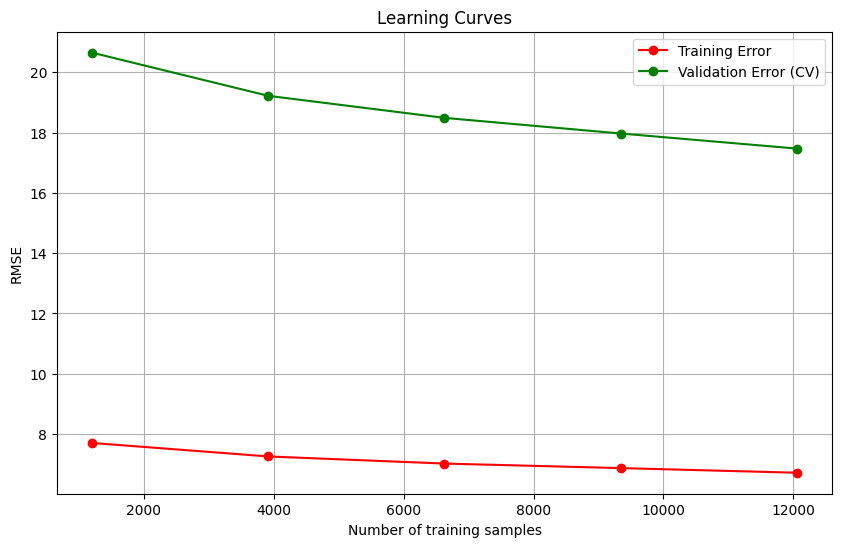

In [364]:
def plot_learning_curves(model, X, y):
    
    # Calculate learning curves
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_root_mean_squared_error', 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    # Convert negative MSE to positive RMSE
    train_errors = -train_scores
    test_errors = -test_scores
    
    mean_train = np.mean(train_errors, axis=1)
    mean_test = np.mean(test_errors, axis=1)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, mean_train, 'o-', color="r", label="Training Error")
    plt.plot(train_sizes, mean_test, 'o-', color="g", label="Validation Error (CV)")
    
    plt.title("Learning Curves")
    plt.xlabel("Number of training samples")
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()


plot_learning_curves(best_rf, X_train, y_train)

### CROSS-VALIDATION 

In [365]:
def check_cv_variance(model, X, y):

    # Compute scores on 5 folds
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    print(" Stability (Cross-Validation) ")
    print(f"R² scores per fold: {scores}")
    print(f"Mean R²: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    
    if scores.std() > 0.05:
        print("Warning: The model is unstable (high variance between folds)")
    else:
        print("The model is stable.")


check_cv_variance(best_rf, X_train, y_train)

 Stability (Cross-Validation) 
R² scores per fold: [0.39053023 0.34058061 0.36410406 0.33715133 0.37945706]
Mean R²: 0.3624
Standard Deviation: 0.0210
The model is stable.
